In [146]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import tensorflow as tf
import tensorflow_decision_forests as tfdf
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/spaceship-titanic/sample_submission.csv
/kaggle/input/spaceship-titanic/train.csv
/kaggle/input/spaceship-titanic/test.csv


In [147]:
print("Tensorflow v "+ tf.__version__)
print("TensorFlow Decision Forests v "+ tfdf.__version__)

Tensorflow v 2.18.0
TensorFlow Decision Forests v 1.11.0


In [148]:
# 1) load data
dataset_df = pd.read_csv('/kaggle/input/spaceship-titanic/train.csv')
print("Full train dataset shape is {}".format(dataset_df.shape))

Full train dataset shape is (8693, 14)


In [149]:
print(dataset_df.head(5))

  PassengerId HomePlanet CryoSleep  Cabin  Destination   Age    VIP  \
0     0001_01     Europa     False  B/0/P  TRAPPIST-1e  39.0  False   
1     0002_01      Earth     False  F/0/S  TRAPPIST-1e  24.0  False   
2     0003_01     Europa     False  A/0/S  TRAPPIST-1e  58.0   True   
3     0003_02     Europa     False  A/0/S  TRAPPIST-1e  33.0  False   
4     0004_01      Earth     False  F/1/S  TRAPPIST-1e  16.0  False   

   RoomService  FoodCourt  ShoppingMall     Spa  VRDeck               Name  \
0          0.0        0.0           0.0     0.0     0.0    Maham Ofracculy   
1        109.0        9.0          25.0   549.0    44.0       Juanna Vines   
2         43.0     3576.0           0.0  6715.0    49.0      Altark Susent   
3          0.0     1283.0         371.0  3329.0   193.0       Solam Susent   
4        303.0       70.0         151.0   565.0     2.0  Willy Santantines   

   Transported  
0        False  
1         True  
2        False  
3        False  
4         True  


In [150]:
# 2) explore data

dataset_df.info() # data explore - dataframe structure

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB


In [151]:
#2) explore data 

dataset_df.describe() #data explore - statistical summary

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,8514.000000,8512.000000,8510.000000,8485.000000,8510.000000,8505.000000
mean,28.827930,224.687617,458.077203,173.729169,311.138778,304.854791
std,14.489021,666.717663,1611.489240,604.696458,1136.705535,1145.717189
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,38.000000,47.000000,76.000000,27.000000,59.000000,46.000000
max,79.000000,14327.000000,29813.000000,23492.000000,22408.000000,24133.000000


In [152]:
# 2) explore data 

plot_df = dataset_df.Transported.value_counts() #data explore - check imbalance
                                                #create a pandas series
print(plot_df) #this is the pandas series

Transported
True     4378
False    4315
Name: count, dtype: int64


<Axes: xlabel='Transported'>

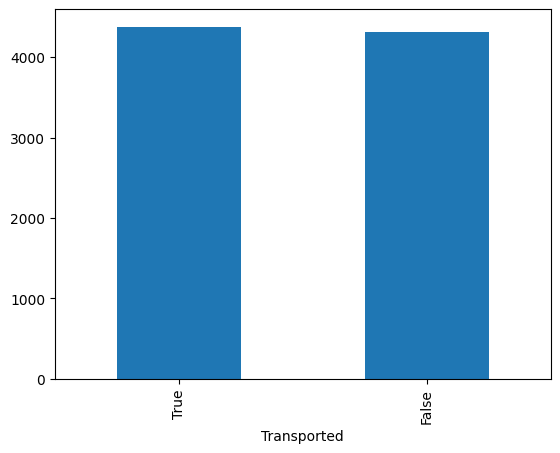

In [153]:
plot_df.plot(kind = "bar") # data (target) explore - visualise 

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  

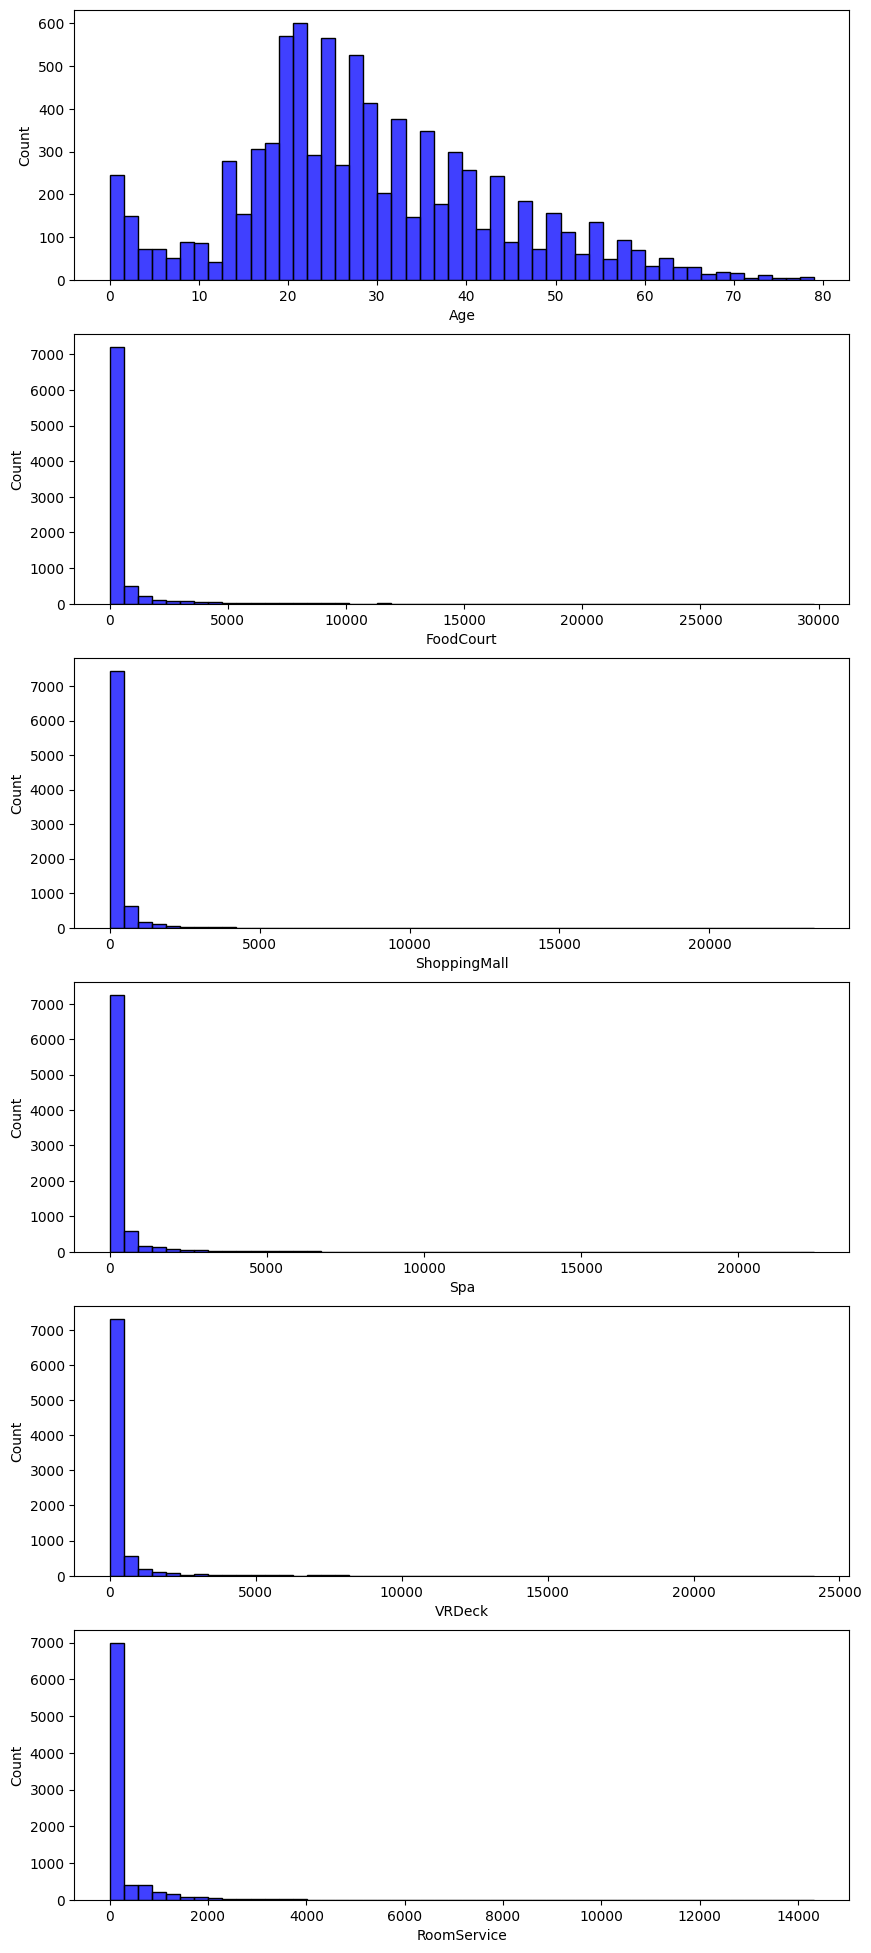

In [154]:
#data (features) explore - visualize

fig, ax = plt.subplots(6,1,  figsize=(10, 10)) 
# fig: refer to the whole window of plot 
# ax: numpy array, each element is a subplot (each subplot: a diagram to visualize a feature)
# .subplots(6,1, figsize(10, 10)): create 6 subplots, each has 1 column with size of 10x10

plt.subplots_adjust(top = 2) #adjust spacing

sns.histplot(dataset_df['Age'], color='b', bins=50, ax=ax[0]); 
#use ax[0] to visualise "Age" feature

sns.histplot(dataset_df['FoodCourt'], color='b', bins=50, ax=ax[1]);
sns.histplot(dataset_df['ShoppingMall'], color='b', bins=50, ax=ax[2]);
sns.histplot(dataset_df['Spa'], color='b', bins=50, ax=ax[3]);
sns.histplot(dataset_df['VRDeck'], color='b', bins=50, ax=ax[4]);
sns.histplot(dataset_df['RoomService'], color='b', bins=50, ax=ax[5]);

In [155]:
# clean data (after explore data)
dataset_df = dataset_df.drop(['PassengerId', 'Name'], axis=1); #drop unnecessary columns
dataset_df.head(5)

,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported
0,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,False
1,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,True
2,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,False
3,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,False
4,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,True


In [156]:
#preprocess data - check missing values
dataset_df.isnull().sum().sort_values(ascending = False)

CryoSleep       217
ShoppingMall    208
VIP             203
HomePlanet      201
Cabin           199
VRDeck          188
FoodCourt       183
Spa             183
Destination     182
RoomService     181
Age             179
Transported       0
dtype: int64

In [157]:
# preprocess data - handle missing values 

#tf-df can handle numeric, categorical and missing features automatically

#fill missing values of float columns (let tf-df deal with categorical ones)
dataset_df[['VIP', 'CryoSleep', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']] = dataset_df[['VIP', 'CryoSleep', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']].fillna(value=0)


#tf-df can't handle boolean columns -> turn values in those columns into int and fill missing ones = 0
label = "Transported"
dataset_df[label] = dataset_df[label].astype(int)
dataset_df["CryoSleep"] = dataset_df["CryoSleep"].astype(int)
dataset_df["VIP"] = dataset_df["VIP"].astype(int)


In [158]:
#preprocessing data - feature engineering 

# Cabin has format Deck/Cabin_num/Side -> split this col into 3 string cols 
dataset_df[["Deck", "Cabin_num", "Side"]] = dataset_df["Cabin"].str.split("/", expand=True)

#drop "Cabin" col
try:
    dataset_df = dataset_df.drop('Cabin', axis=1)
except KeyError:
    print("Field does not exist")

# 5 features reflect 1 thing: spending amount -> group into 1 feature to consolidate signal
dataset_df["TotalSpend"] = dataset_df["RoomService"]+dataset_df["FoodCourt"]+dataset_df["Spa"]+dataset_df["VRDeck"]+dataset_df["ShoppingMall"]

In [159]:
#split data (after finish preprocessing and cleaning): split train data -> train & validation
train_ds_pd, valid_ds_pd = train_test_split(dataset_df, test_size = 0.2, random_state =42)

In [160]:
#change data type of the dataset: Pandas Dataframe -> Tensorflow dataset
train_ds = tfdf.keras.pd_dataframe_to_tf_dataset(train_ds_pd, label = label)
valid_ds = tfdf.keras.pd_dataframe_to_tf_dataset(valid_ds_pd, label = label)

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


In [161]:
#Select a model (random forest)
rf = tfdf.keras.RandomForestModel(num_trees=161)
rf.compile(metrics = ["accuracy"])

Use /tmp/tmpppsv2rs_ as temporary training directory


In [162]:
# train model
rf.fit(x=train_ds)

Reading training dataset...
Training dataset read in 0:00:00.343624. Found 6954 examples.
Training model...


I0000 00:00:1764478308.935058      47 kernel.cc:782] Start Yggdrasil model training
I0000 00:00:1764478308.935097      47 kernel.cc:783] Collect training examples
I0000 00:00:1764478308.935109      47 kernel.cc:795] Dataspec guide:
column_guides {
  column_name_pattern: "^__LABEL$"
  type: CATEGORICAL
  categorial {
    min_vocab_frequency: 0
    max_vocab_count: -1
  }
}
default_column_guide {
  categorial {
    max_vocab_count: 2000
  }
  discretized_numerical {
    maximum_num_bins: 255
  }
}
ignore_columns_without_guides: false
detect_numerical_as_discretized_numerical: false

I0000 00:00:1764478308.935236      47 kernel.cc:401] Number of batches: 7
I0000 00:00:1764478308.935256      47 kernel.cc:402] Number of examples: 6954
I0000 00:00:1764478308.938186      47 data_spec_inference.cc:354] 1269 item(s) have been pruned (i.e. they are considered out of dictionary) for the column Cabin_num (478 item(s) left) because min_value_count=5 and max_number_of_unique_values=2000
I0000 00:00:

Model trained in 0:00:26.523150
Compiling model...


I0000 00:00:1764478335.423737      47 decision_forest.cc:761] Model loaded with 161 root(s), 128079 node(s), and 14 input feature(s).
I0000 00:00:1764478335.423788      47 abstract_model.cc:1404] Engine "RandomForestGeneric" built


Model compiled.


In [163]:
#visualise (not a mandatory step in the process)
tfdf.model_plotter.plot_model_in_colab(rf, tree_idx=0, max_depth=3)

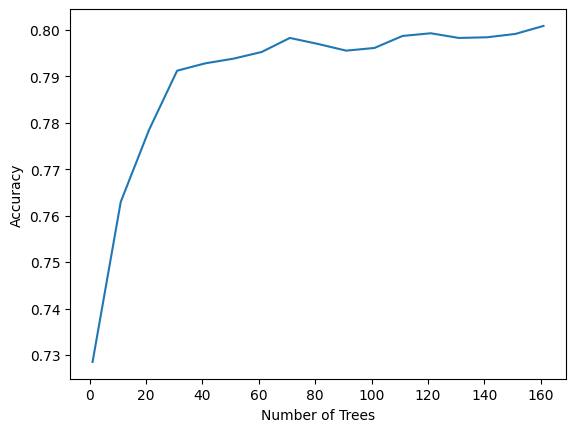

In [164]:
#Evaluate model using Out Of Bag score (use train data)

logs = rf.make_inspector().training_logs() 
#training_logs() return a list of trials
#make_inspector() return the accuracy of each trial 
#logs: record of all trials 

plt.plot([log.num_trees for log in logs], [log.evaluation.accuracy for log in logs])
plt.xlabel("Number of Trees")
plt.ylabel("Accuracy")
plt.show()

In [165]:
# # Settings
# limit = 200
# tolerance = 0.001

# # 1. Filter logs
# filtered_logs = [log for log in logs if log.num_trees < limit]

# # 2. Find Absolute Max
# best_log = max(filtered_logs, key=lambda x: x.evaluation.accuracy)
# max_acc = best_log.evaluation.accuracy

# # 3. Find Efficient Best (Elbow Point)
# target_acc = max_acc - tolerance
# optimal_log = best_log # Default fallback

# for log in filtered_logs:
#     if log.evaluation.accuracy >= target_acc:
#         optimal_log = log
#         break

# # 4. Simple Output
# print(f"Absolute Max:    {max_acc:.5f} (at {best_log.num_trees} trees)")
# print(f"Efficient Best:  {optimal_log.evaluation.accuracy:.5f} (at {optimal_log.num_trees} trees)")

In [166]:
#Evaluate on Validation data

evaluation = rf.evaluate(x=valid_ds,return_dict=True)

for name, value in evaluation.items():
  print(f"{name}: {value:.4f}")



2/2 [==============================] - 0s 35ms/step - loss: 0.0000e+00 - accuracy: 0.7953
loss: 0.0000
accuracy: 0.7953
